In [23]:
import sys,copy,os,inspect
if hasattr(sys.modules[__name__], '__file__'):
    _file_name = __file__
else:
    _file_name = inspect.getfile(inspect.currentframe())
CURRENT_FILE_PATH = os.path.dirname(_file_name)
sys.path.append(os.getcwd()+"/../neuronVis")

import sys,os
from skimage import measure,io
import IONData
import nrrd
from sklearn.cluster import KMeans
import numpy as np
import trimesh
import matplotlib.pyplot as plt

In [18]:
iondata = IONData.IONData()
resISOCLA,isoclaPath=iondata.getFileFromServer('maskISO_CLA-1.nrrd')
resBoundary,boundaryPath=iondata.getFileFromServer('isocortex_boundary_10-2.nrrd')
mask_combined,CLAHeader = nrrd.read(isoclaPath,index_order='F')
boundary,boundaryHeader = nrrd.read(boundaryPath,index_order='F')



In [19]:
from scipy.ndimage import binary_dilation
t3= boundary>=53
# diatedCropMask3=binary_dilation(t3,None,iterations=6)
diatedCropMask3 = t3.astype(np.int8)

t1= boundary==51
# diatedCropMask=binary_dilation(t1,None,iterations=6)
diatedCropMask = t1.astype(np.int8)
# nrrd.write('../resource/boundaryout.nrrd',diatedCropMask)

In [20]:
mask = np.ones_like( diatedCropMask)
mask = mask*20
mask[diatedCropMask3==1]=0
mask[diatedCropMask==1]=10
mask[mask_combined==1]=5
nrrd.write('../resource/boundaryout.nrrd',mask)

In [2]:

iondata = IONData.IONData()
resISOCLA,isoclaPath=iondata.getFileFromServer('mask_combinedISO_CLA.nrrd')
resBoundary,boundaryPath=iondata.getFileFromServer('isocortex_boundary_10.nrrd')
mask_combined,CLAHeader = nrrd.read(isoclaPath,index_order='F')
verts, faces, t1, t2 = measure.marching_cubes(mask_combined, 0,method='lorensen')
boundary,boundaryHeader = nrrd.read(boundaryPath,index_order='F')

[ROW, COL, SLICE] = mask_combined.shape

print('step2: Get the surface form mask')
verts, faces, t1, t2 = measure.marching_cubes(mask_combined, 0,method='lorensen')

mesh = trimesh.Trimesh(vertices=verts,
                            faces=faces,
                            )
x,y,z=np.where(boundary==1)
boundaryvert = np.hstack((x.reshape(-1,1),y.reshape(-1,1),z.reshape(-1,1)))
verts = mesh.vertices.astype(np.uint64)
faces = mesh.faces

print('step3: Get superficial part from the surface')
vertsflat=verts[:,0]+verts[:,1]*ROW+verts[:,2]*ROW*COL
boundaryvertflat=boundaryvert[:,0]+boundaryvert[:,1]*ROW+boundaryvert[:,2]*ROW*COL
# vertsback = np.array([(vertsflat%ROW).astype(np.Uint64),((vertsflat/ROW).astype(np.Uint64)%COL).astype(np.Uint64),((vertsflat/COL).astype(np.Uint64)/ROW).astype(np.Uint64)])
flag_vertex_superficial=np.in1d(vertsflat,boundaryvertflat)
faceflag=flag_vertex_superficial[mesh.faces]
flag_face_superficial=sum(faceflag.T)==3

index=faces[flag_face_superficial==1,:]

print('step4: Calculate the shortest path to anchor_center [649,57, 349]')
indexx=index[:,0];
indexy=index[:,1];
indexz=index[:,2];

coordx=verts[indexx,:]
coordy=verts[indexy,:]
coordz=verts[indexz,:]


step2: Get the surface form mask
step3: Get superficial part from the surface
step4: Calculate the shortest path to anchor_center [649,57, 349]


In [13]:
verts

TrackedArray([[ 181,  254,  495],
              [ 182,  254,  494],
              [ 182,  253,  495],
              ...,
              [1037,  242,  221],
              [1037,  242,  222],
              [1037,  242,  223]], dtype=uint64)

In [20]:
len(verts[flag_vertex_superficial])

734466

In [3]:
len(verts)
estimator=KMeans(n_clusters=200,max_iter=1500)
res=estimator.fit_predict(verts[flag_vertex_superficial])

In [6]:
boundary.shape[0]

1320

In [8]:
lable_pred=estimator.labels_
print(len(lable_pred))
print(lable_pred)
isocluster = np.zeros((int(boundary.shape[0]/2),int(boundary.shape[1]/2),int(boundary.shape[2]/2)))
superficialverts = verts[flag_vertex_superficial]
for i in range(len(superficialverts)):
    isocluster[int(superficialverts[i][0]/2),int(superficialverts[i][1]/2),int(superficialverts[i][2]/2)] = lable_pred[i]+1

734466
[73 73 73 ... 62 62 62]


In [27]:
isocluster=isocluster.astype(np.uint8)

In [28]:
nrrd.write("../resource/isocluster.nrrd",isocluster)

(-0.5, 1499.5, 1499.5, -0.5)

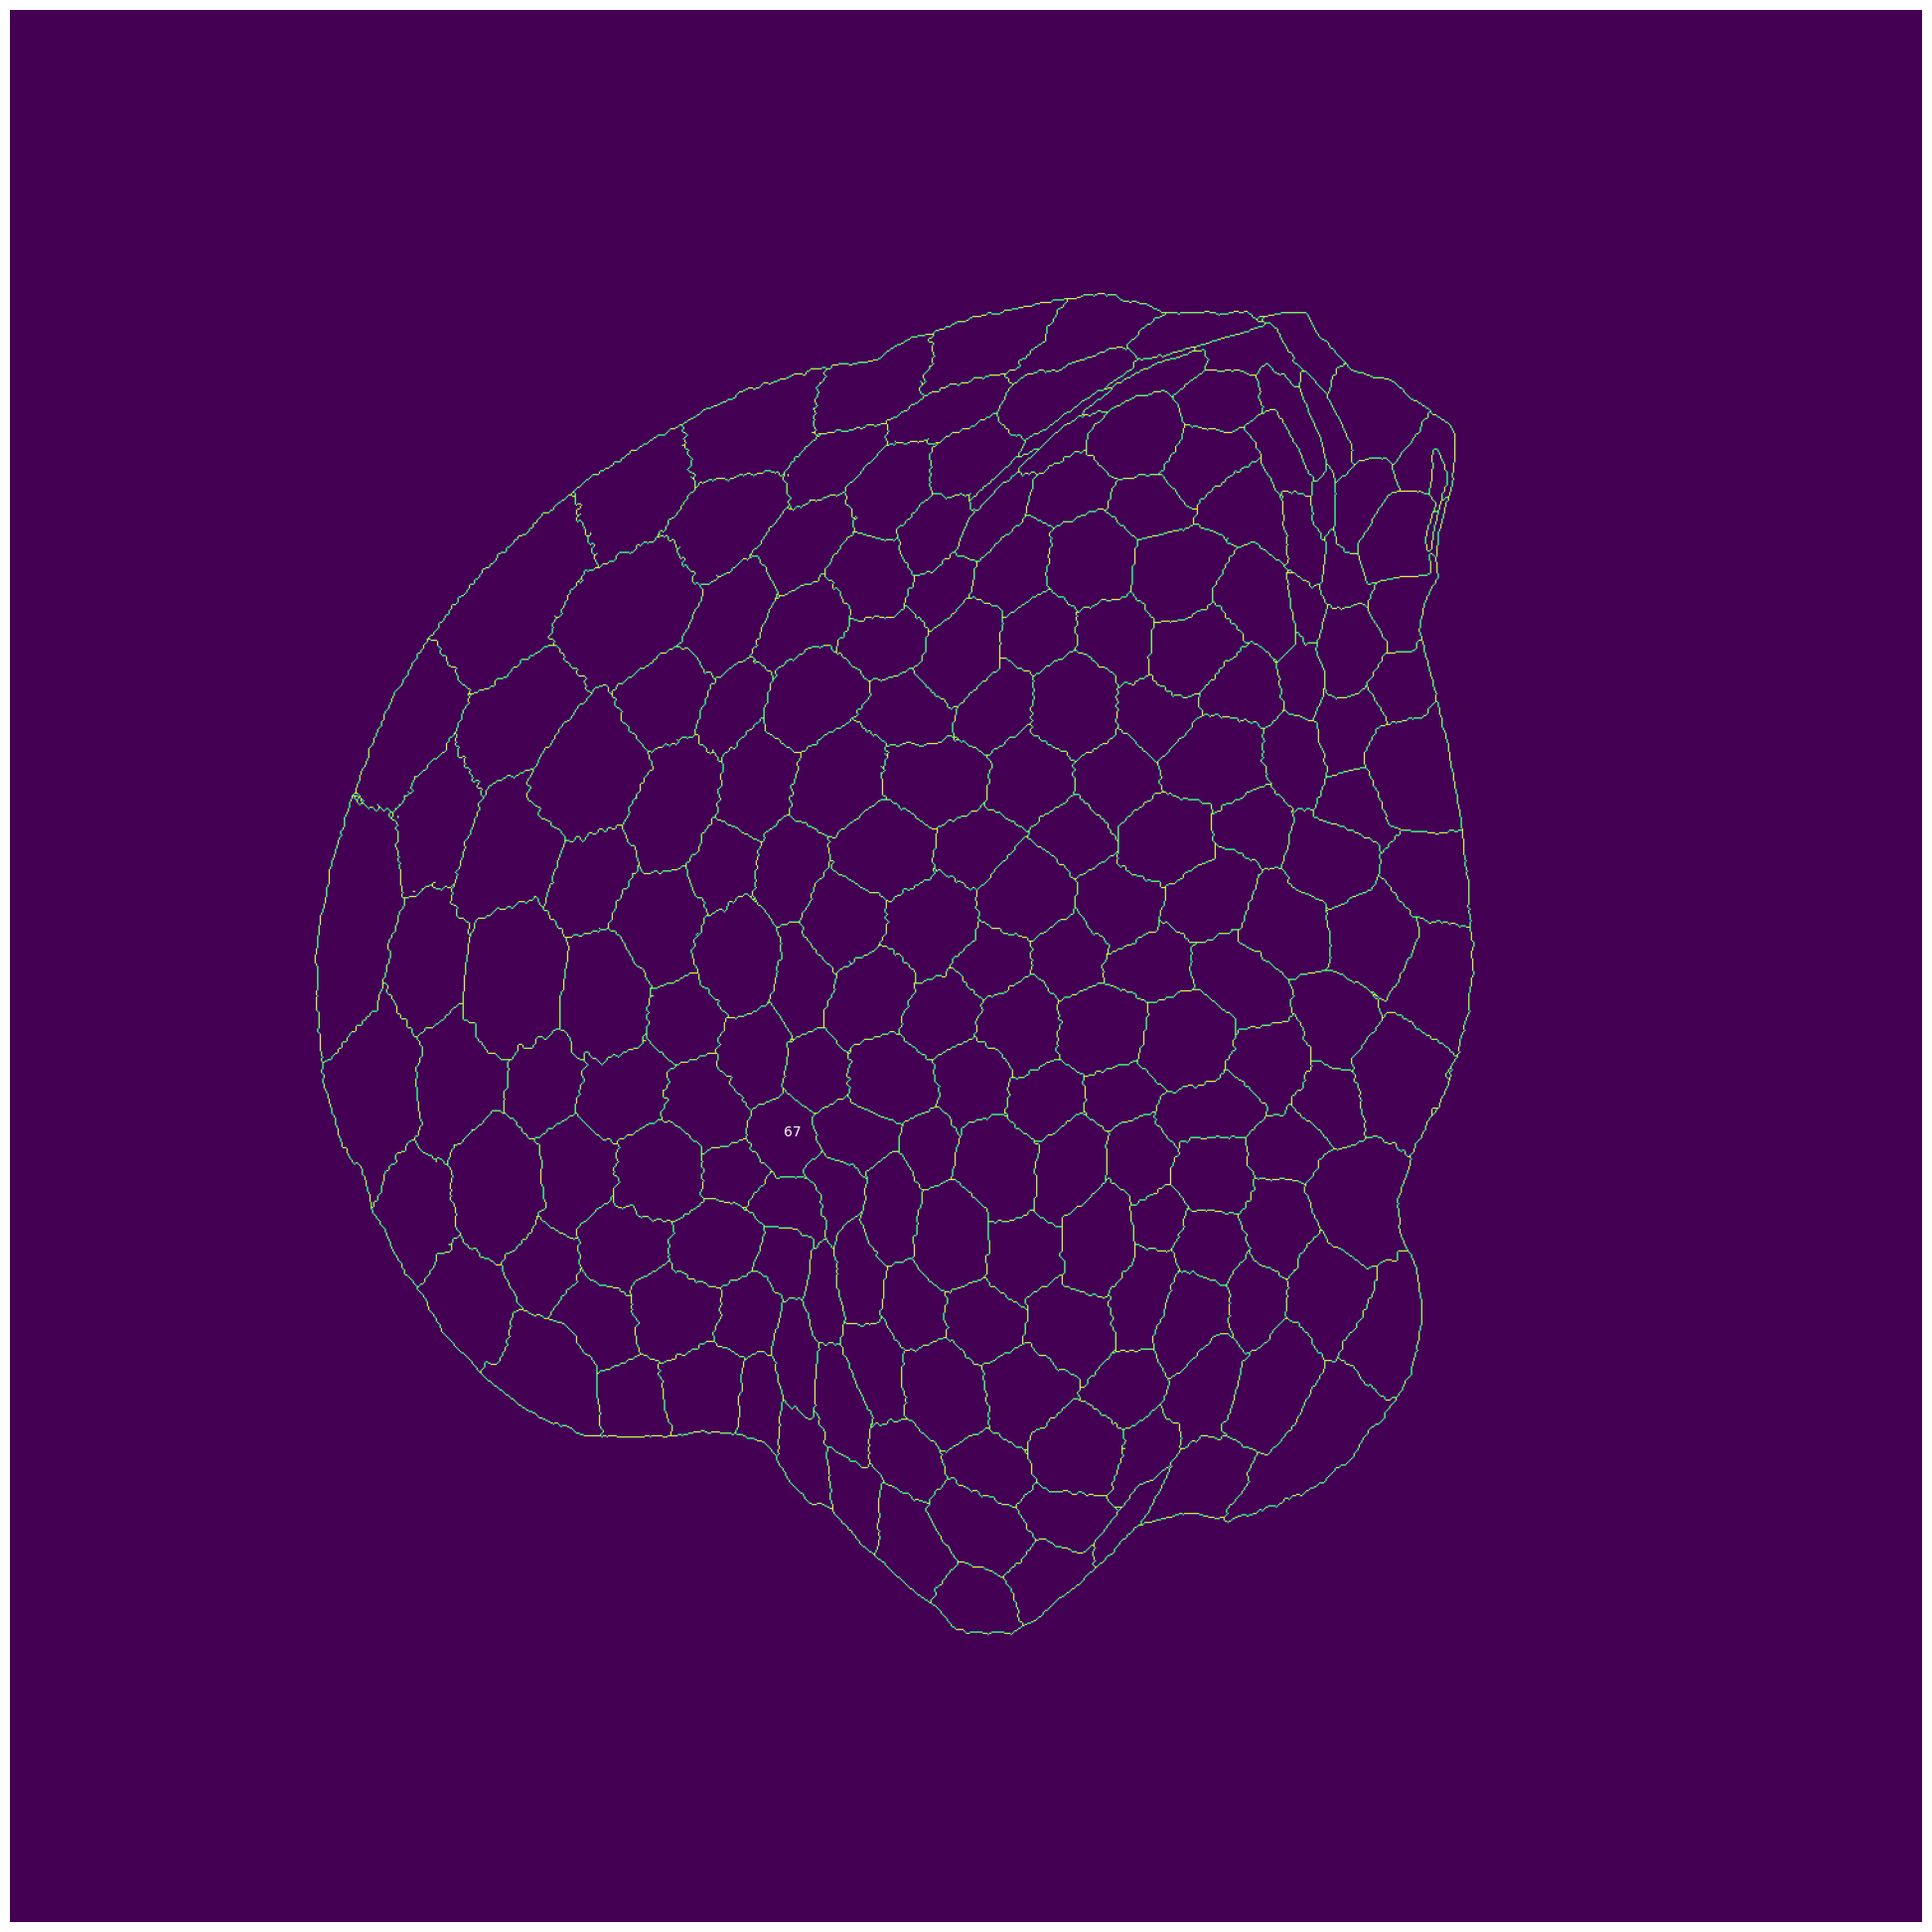

In [42]:

%matplotlib inline
fig,ax = plt.subplots(figsize=(25,25))
image = io.imread('../resource/isomoduleflatmap.png')
edge = io.imread('../resource/isomoduleflatmap-1.png')
flatmapedge = io.imread('../resource/flatmapedge.png')
# edge[flatmapedge[:,:,0]==0]=255
for i in range(1,200):
    if i==67:
        coord0 = np.array(np.where(image==i))
        coord = coord0.mean(1)
        plt.text(coord[1], coord[0], str(i),color='white')
plt.imshow(edge)
plt.axis('off')
# io.imshow(image)
# for i in range(200):
#     print(i)

